# Book 3 — GraphSAGE Spatial Extension for Three-Class Urban Morphology

This notebook tests whether adding spatial neighbourhood structure improves urban-village detection beyond the tabular RF/XGBoost baselines. It runs in Google Colab after Book 2 has saved the processed grid table and feature list.

**Input**: `book3_gnn_input.csv`, `book3_gnn_input.geojson`, and `book3_feature_cols.json` from Book 2.  
**Output**: GraphSAGE metrics, training history, confusion matrix, and prediction layers.  
**Runtime**: typically 10-25 minutes on a Colab GPU.  
**Role in the pipeline**: provides the headline spatial model by treating neighbouring grid cells as a graph rather than independent tabular rows.


### Step 0: Mount Google Drive

**Purpose**: Connect Colab to the processed files written by Book 2 and the output folder used by Book 3.  
**Input**: Google Drive authentication.  
**Output**: mounted Drive path for graph-model inputs and outputs.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 1: Import libraries and define paths

**Purpose**: Load the PyTorch, geospatial, nearest-neighbour, and metric libraries required to train GraphSAGE from scratch.  
**Input**: Colab runtime and project folder layout.  
**Output**: class constants, file paths, and reproducibility settings.


In [3]:
# ----------------------------------------------------------------------------
# 1. Imports and paths
# ----------------------------------------------------------------------------

!pip -q install codecarbon geopandas

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

# Same three-class scheme used in Book 2
CLASS_GREEN = 0
CLASS_NORMAL = 1
CLASS_VILLAGE = 2
CLASS_ORDER = [CLASS_GREEN, CLASS_NORMAL, CLASS_VILLAGE]
CLASS_NAMES = {
    CLASS_GREEN: "urban_green",
    CLASS_NORMAL: "normal_built_up",
    CLASS_VILLAGE: "urban_village",
}
CLASS_LABELS_ORDERED = [CLASS_NAMES[c] for c in CLASS_ORDER]
NUM_CLASSES = len(CLASS_ORDER)

try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
except Exception:
    CODECARBON_AVAILABLE = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/0069/week10")
PROCESSED_DIR = PROJECT_DIR / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.5/380.5 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 125.0 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


### Step 2: Load the Book 2 processed table

**Purpose**: Reuse the exact same weak labels and feature columns as the tabular models.  
**Input**: Book 2 CSV/GeoJSON outputs and `book3_feature_cols.json`.  
**Output**: a clean DataFrame and GeoDataFrame ready for graph construction.


In [4]:
# ----------------------------------------------------------------------------
# 2. Load Book 2 processed table
# ----------------------------------------------------------------------------

df = pd.read_csv(PROCESSED_DIR / "book3_gnn_input.csv")
geo_path = PROCESSED_DIR / "book3_gnn_input.geojson"
geometry_gdf = None
if geo_path.exists():
    geometry_gdf = gpd.read_file(geo_path)

with open(PROCESSED_DIR / "book3_feature_cols.json", "r") as f:
    feature_cols = json.load(f)

df = df[df["weak_label"].isin(CLASS_ORDER)].copy()
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

# Match Book 2's missing-value semantics. Sentinel-1 orbit-pass gaps are
# physical missing observations, so fill S1 bands with 0 and let the
# s1_*_has_data flags route the model. Other numeric features use medians.
s1_cols = [c for c in feature_cols if c.startswith("s1_")]
non_s1_cols = [c for c in feature_cols if c not in s1_cols]
if s1_cols:
    df[s1_cols] = df[s1_cols].fillna(0)
if non_s1_cols:
    df[non_s1_cols] = df[non_s1_cols].fillna(df[non_s1_cols].median(numeric_only=True))

print(df.shape)
print(df["city"].value_counts())
print(df["weak_label"].value_counts())

(127899, 88)
city
shanghai     33249
tianjin      18346
beijing      15122
guangzhou    13785
chengdu      11830
dongguan      9812
shenzhen      8877
xian          6664
wuhan         5836
chongqing     4378
Name: count, dtype: int64
weak_label
1    115246
0     11249
2      1404
Name: count, dtype: int64


### Step 3: Create train, validation, and test masks

**Purpose**: Preserve cross-city evaluation while using Beijing as an inner validation city for early stopping.  
**Input**: city names and weak labels.  
**Output**: Boolean masks for train, validation, and held-out test nodes.


In [5]:
# ----------------------------------------------------------------------------
# 3. Create cross-city train/validation/test masks
# ----------------------------------------------------------------------------
# GraphSAGE uses an inner validation city for early stopping. This prevents
# peeking at the final held-out test cities during training.
#
# Preferred split:
# - train on Guangzhou/Shenzhen/Tianjin
# - validate on Beijing
# - final test on Xi'an/Dongguan/Shanghai/Chengdu/Chongqing/Wuhan

available_cities = sorted(df["city"].unique())
TRAIN_CITIES_INNER = [c for c in ["guangzhou", "shenzhen", "tianjin", "xian", "chongqing"] if c in available_cities]
VAL_CITIES = [c for c in ["beijing"] if c in available_cities]
TEST_CITIES = [c for c in ["dongguan", "shanghai", "chengdu", "wuhan"] if c in available_cities]

if len(TRAIN_CITIES_INNER) >= 1 and len(VAL_CITIES) >= 1 and len(TEST_CITIES) >= 1:
    train_mask_np = df["city"].isin(TRAIN_CITIES_INNER).values
    val_mask_np = df["city"].isin(VAL_CITIES).values
    test_mask_np = df["city"].isin(TEST_CITIES).values
    split_name = (
        f"cross_city_train_{'_'.join(TRAIN_CITIES_INNER)}"
        f"_val_{'_'.join(VAL_CITIES)}"
        f"_test_{'_'.join(TEST_CITIES)}"
    )
else:
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(df))
    train_idx, holdout_idx = train_test_split(
        idx,
        test_size=0.40,
        stratify=df["weak_label"],
        random_state=RANDOM_STATE,
    )
    val_idx, test_idx = train_test_split(
        holdout_idx,
        test_size=0.50,
        stratify=df.iloc[holdout_idx]["weak_label"],
        random_state=RANDOM_STATE,
    )
    train_mask_np = np.zeros(len(df), dtype=bool)
    val_mask_np = np.zeros(len(df), dtype=bool)
    test_mask_np = np.zeros(len(df), dtype=bool)
    train_mask_np[train_idx] = True
    val_mask_np[val_idx] = True
    test_mask_np[test_idx] = True
    split_name = "stratified_random_train_val_test_split"

print(split_name)
print("Train size:", train_mask_np.sum())
print("Validation size:", val_mask_np.sum())
print("Test size:", test_mask_np.sum())

n_train_classes = len(np.unique(df.loc[train_mask_np, "weak_label"]))
if n_train_classes < 2:
    raise ValueError(
        "Training split has only one class. Relax weak-label thresholds or add more candidate data."
    )
if n_train_classes < NUM_CLASSES:
    print(f"WARNING: training split has only {n_train_classes} of {NUM_CLASSES} classes.")

cross_city_train_guangzhou_shenzhen_tianjin_xian_chongqing_val_beijing_test_dongguan_shanghai_chengdu_wuhan
Train size: 52050
Validation size: 15122
Test size: 60727


### Step 4: Build node features and the k-nearest-neighbour graph

**Purpose**: Standardise grid features and connect each grid to nearby grids within the same city.  
**Input**: feature columns, centroid coordinates, and city identifiers.  
**Output**: PyTorch tensors for node features, labels, masks, and graph edges.


In [6]:
# ----------------------------------------------------------------------------
# 4. Build node features and k-nearest-neighbour graph
# ----------------------------------------------------------------------------
# Edges are created within each city only. This prevents Guangzhou grids from
# connecting to Xi'an grids just because of table ordering.

scaler = StandardScaler()
X_np = df[feature_cols].values.astype("float32")
scaler.fit(X_np[train_mask_np])
X_np = scaler.transform(X_np).astype("float32")

y_np = df["weak_label"].values.astype("int64")

def build_knn_edges_by_city(dataframe, k=8):
    sources = []
    targets = []

    for city, sub in dataframe.groupby("city"):
        idx = sub.index.to_numpy()
        coords = sub[["centroid_lon", "centroid_lat"]].values

        if len(sub) <= k:
            continue

        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm="ball_tree").fit(coords)
        _, neigh = nbrs.kneighbors(coords)

        for local_i, local_neighs in enumerate(neigh):
            src = idx[local_i]
            for local_j in local_neighs[1:]:
                tgt = idx[local_j]
                sources.append(src)
                targets.append(tgt)
                sources.append(tgt)
                targets.append(src)

    edge_index = np.vstack([sources, targets]).astype("int64")
    return edge_index

edge_index_np = build_knn_edges_by_city(df.reset_index(drop=True), k=8)

print("Number of directed edges:", edge_index_np.shape[1])

X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
y = torch.tensor(y_np, dtype=torch.long, device=DEVICE)
edge_index = torch.tensor(edge_index_np, dtype=torch.long, device=DEVICE)
train_mask = torch.tensor(train_mask_np, dtype=torch.bool, device=DEVICE)
val_mask = torch.tensor(val_mask_np, dtype=torch.bool, device=DEVICE)
test_mask = torch.tensor(test_mask_np, dtype=torch.bool, device=DEVICE)

Number of directed edges: 2046384


### Step 5: Define the pure-PyTorch GraphSAGE model

**Purpose**: Implement GraphSAGE message passing without relying on PyTorch Geometric, keeping the notebook easier to run in Colab.  
**Input**: feature dimension, hidden size, dropout, and number of classes.  
**Output**: a two-layer GraphSAGE classifier that combines each node's features with aggregated neighbour features.


In [7]:
# ----------------------------------------------------------------------------
# 5. Pure PyTorch GraphSAGE layer
# ----------------------------------------------------------------------------
# For each node:
# 1. average neighbour features
# 2. concatenate self features and neighbour mean
# 3. apply a linear layer

class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, x, edge_index):
        src, dst = edge_index
        agg = torch.zeros_like(x)
        deg = torch.zeros(x.size(0), device=x.device)

        agg.index_add_(0, dst, x[src])
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=torch.float32))
        deg = deg.clamp(min=1).unsqueeze(1)
        neigh_mean = agg / deg

        out = torch.cat([x, neigh_mean], dim=1)
        return self.linear(out)

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.35, num_classes=NUM_CLASSES):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.sage2 = GraphSAGELayer(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.sage1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.sage2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

### Step 6: Train GraphSAGE with validation-based early stopping

**Purpose**: Optimise the graph model using class-weighted cross entropy and select the best epoch using validation macro-F1.  
**Input**: graph tensors, train/validation masks, and class weights.  
**Output**: trained model weights and a training-history table.


In [8]:
# ----------------------------------------------------------------------------
# 6. Train GraphSAGE
# ----------------------------------------------------------------------------

model = GraphSAGE(in_dim=X.shape[1], hidden_dim=64, dropout=0.35,
                  num_classes=NUM_CLASSES).to(DEVICE)

# Inverse-frequency class weights over the 3 classes
class_counts = np.bincount(y_np[train_mask_np], minlength=NUM_CLASSES)
class_weights = class_counts.sum() / np.maximum(class_counts, 1)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights (green, normal, village):", class_weights.cpu().numpy())

optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

best_state = None
best_val_macro_f1 = -1
history = []

tracker = None
if CODECARBON_AVAILABLE:
    tracker = EmissionsTracker(
        project_name="0069_urban_village_graphsage",
        output_dir=str(OUTPUT_DIR),
        output_file="book3_codecarbon_emissions.csv",
        log_level="error",
    )
    tracker.start()

for epoch in range(1, 301):
    model.train()
    optimizer.zero_grad()
    logits = model(X, edge_index)
    loss = loss_fn(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(X, edge_index)
        probs = logits.softmax(dim=1).detach().cpu().numpy()    # (n_nodes, n_classes)
        pred = probs.argmax(axis=1).astype(np.int64)

    train_macro_f1 = f1_score(
        y_np[train_mask_np], pred[train_mask_np],
        average="macro", labels=CLASS_ORDER, zero_division=0,
    )
    val_macro_f1 = f1_score(
        y_np[val_mask_np], pred[val_mask_np],
        average="macro", labels=CLASS_ORDER, zero_division=0,
    )
    test_macro_f1 = f1_score(
        y_np[test_mask_np], pred[test_mask_np],
        average="macro", labels=CLASS_ORDER, zero_division=0,
    )
    test_village_f1 = f1_score(
        y_np[test_mask_np], pred[test_mask_np],
        average=None, labels=CLASS_ORDER, zero_division=0,
    )[CLASS_ORDER.index(CLASS_VILLAGE)]

    history.append({
        "epoch": epoch,
        "loss": float(loss.item()),
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": val_macro_f1,
        "test_macro_f1": test_macro_f1,
        "test_village_f1": test_village_f1,
    })

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 25 == 0:
        print(f"epoch={epoch:03d} loss={loss.item():.4f}  "
              f"train_macroF1={train_macro_f1:.3f}  "
              f"val_macroF1={val_macro_f1:.3f}  "
              f"test_macroF1={test_macro_f1:.3f}  "
              f"test_villageF1={test_village_f1:.3f}")

if tracker is not None:
    emissions = tracker.stop()
    print("Estimated emissions kgCO2e:", emissions)

model.load_state_dict(best_state)

pd.DataFrame(history).to_csv(OUTPUT_DIR / f"book3_graphsage_training_history_{split_name}.csv", index=False)

Class weights (green, normal, village): [13.0125     1.0989591 75.76419  ]


[codecarbon WARNING @ 18:01:47] Multiple instances of codecarbon are allowed to run at the same time.


epoch=025 loss=0.2468  train_macroF1=0.629  val_macroF1=0.798  test_macroF1=0.555  test_villageF1=0.135
epoch=050 loss=0.1482  train_macroF1=0.713  val_macroF1=0.838  test_macroF1=0.633  test_villageF1=0.215
epoch=075 loss=0.0989  train_macroF1=0.756  val_macroF1=0.841  test_macroF1=0.702  test_villageF1=0.279
epoch=100 loss=0.0791  train_macroF1=0.781  val_macroF1=0.854  test_macroF1=0.745  test_villageF1=0.305
epoch=125 loss=0.0565  train_macroF1=0.815  val_macroF1=0.888  test_macroF1=0.778  test_villageF1=0.368
epoch=150 loss=0.0476  train_macroF1=0.858  val_macroF1=0.885  test_macroF1=0.806  test_villageF1=0.445
epoch=175 loss=0.0390  train_macroF1=0.887  val_macroF1=0.892  test_macroF1=0.822  test_villageF1=0.490
epoch=200 loss=0.0353  train_macroF1=0.875  val_macroF1=0.908  test_macroF1=0.814  test_villageF1=0.460
epoch=225 loss=0.0295  train_macroF1=0.899  val_macroF1=0.910  test_macroF1=0.832  test_villageF1=0.509
epoch=250 loss=0.0260  train_macroF1=0.898  val_macroF1=0.909  t

### Step 7: Evaluate GraphSAGE on held-out cities

**Purpose**: Compare the spatial model with Book 2 baselines using the same per-class and macro metrics.  
**Input**: best GraphSAGE model and test mask.  
**Output**: classification report, confusion matrix, and metric CSV.


{'model': 'GraphSAGE_k8', 'split': 'cross_city_train_guangzhou_shenzhen_tianjin_xian_chongqing_val_beijing_test_dongguan_shanghai_chengdu_wuhan', 'macro_f1': 0.8581491748186147, 'weighted_f1': 0.9940344018230414, 'balanced_acc': np.float64(0.9027608644115234), 'macro_precision': 0.8276944794136178, 'macro_recall': 0.9027608644115234, 'f1_urban_green': np.float64(0.9976124154397135), 'f1_normal_built_up': np.float64(0.9964076624469519), 'f1_urban_village': np.float64(0.5804274465691789)}
                 precision    recall  f1-score   support

    urban_green      0.996     0.999     0.998      5020
normal_built_up      0.998     0.995     0.996     55346
  urban_village      0.489     0.715     0.580       361

       accuracy                          0.993     60727
      macro avg      0.828     0.903     0.858     60727
   weighted avg      0.995     0.993     0.994     60727

Confusion matrix (rows=true, cols=pred):
                 urban_green  normal_built_up  urban_village
urba

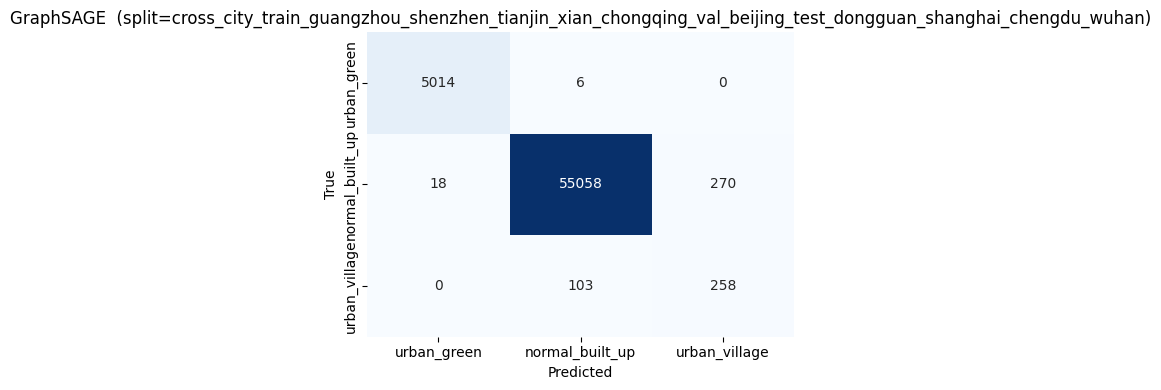

In [9]:
# ----------------------------------------------------------------------------
# 7. Evaluate GraphSAGE
# ----------------------------------------------------------------------------

model.eval()
with torch.no_grad():
    logits = model(X, edge_index)
    probs = logits.softmax(dim=1).detach().cpu().numpy()       # (n_nodes, n_classes)
    pred = probs.argmax(axis=1).astype(np.int64)

y_test = y_np[test_mask_np]
probs_test = probs[test_mask_np]                                # per-class probability
pred_test = pred[test_mask_np]

per_class_f1 = f1_score(y_test, pred_test, average=None, labels=CLASS_ORDER, zero_division=0)
metrics = {
    "model": "GraphSAGE_k8",
    "split": split_name,
    "macro_f1": f1_score(y_test, pred_test, average="macro", labels=CLASS_ORDER, zero_division=0),
    "weighted_f1": f1_score(y_test, pred_test, average="weighted", labels=CLASS_ORDER, zero_division=0),
    "balanced_acc": balanced_accuracy_score(y_test, pred_test),
    "macro_precision": precision_score(y_test, pred_test, average="macro", labels=CLASS_ORDER, zero_division=0),
    "macro_recall": recall_score(y_test, pred_test, average="macro", labels=CLASS_ORDER, zero_division=0),
}
for cls, f1_val in zip(CLASS_ORDER, per_class_f1):
    metrics[f"f1_{CLASS_NAMES[cls]}"] = f1_val

print(metrics)
print(classification_report(
    y_test, pred_test,
    labels=CLASS_ORDER, target_names=CLASS_LABELS_ORDERED,
    digits=3, zero_division=0,
))
cm = confusion_matrix(y_test, pred_test, labels=CLASS_ORDER)
cm_df = pd.DataFrame(cm, index=CLASS_LABELS_ORDERED, columns=CLASS_LABELS_ORDERED)
print("Confusion matrix (rows=true, cols=pred):")
print(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"GraphSAGE  (split={split_name})")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"book3_confusion_GraphSAGE_{split_name}.png", dpi=200)
plt.show()

pd.DataFrame([metrics]).to_csv(OUTPUT_DIR / f"book3_graphsage_metrics_{split_name}.csv", index=False)

### Step 8: Save GraphSAGE predictions

**Purpose**: Export node-level predictions and probabilities for mapping and later uncertainty comparison.  
**Input**: model logits, probabilities, labels, and optional grid geometries.  
**Output**: prediction CSV and GeoJSON layers for the output directory.


In [10]:
# ----------------------------------------------------------------------------
# 8. Save GNN predictions
# ----------------------------------------------------------------------------

out = df.copy()
# Per-class probabilities
for class_idx, cls in enumerate(CLASS_ORDER):
    out[f"gnn_prob_{CLASS_NAMES[cls]}"] = probs[:, class_idx]
out["gnn_prediction"] = pred
out["gnn_prediction_name"] = pd.Series(pred).map(CLASS_NAMES).values
out["gnn_village_probability"] = probs[:, CLASS_ORDER.index(CLASS_VILLAGE)]
# Prediction entropy: higher = more uncertain
out["gnn_pred_entropy"] = -np.sum(probs * np.log(np.clip(probs, 1e-9, 1)), axis=1)
out["is_train"] = train_mask_np
out["is_val"] = val_mask_np
out["is_test"] = test_mask_np

out.to_csv(OUTPUT_DIR / f"book3_graphsage_predictions_{split_name}.csv", index=False)

if geometry_gdf is not None:
    join_cols = ["city", "grid_id"]
    map_cols = join_cols + [
        f"gnn_prob_{CLASS_NAMES[cls]}" for cls in CLASS_ORDER
    ] + [
        "gnn_prediction", "gnn_prediction_name", "gnn_village_probability",
        "gnn_pred_entropy", "is_train", "is_val", "is_test",
    ]
    geometry_out = geometry_gdf.merge(out[map_cols], on=join_cols, how="left")
    geometry_out.to_file(
        OUTPUT_DIR / f"book3_graphsage_predictions_{split_name}.geojson",
        driver="GeoJSON",
    )

print("Saved Book 3 outputs to:", OUTPUT_DIR)

Saved Book 3 outputs to: /content/drive/MyDrive/0069/week10/outputs
